In [1]:
!pip install ipywidgets scikit-network --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [3]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_12439/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_12439/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


In [4]:
data = data.drop(data[data["position"] == "team"].index) 

In [5]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = data[data["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data.drop(games_with_missing_playerids.index)


there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


In [6]:
uniq_player_ids = data["playerid"].unique()
print(len(uniq_player_ids))
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
playerid_to_league = dict(zip(data["playerid"], data["league"]))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

2567


In [7]:
# For each playerid, print the number of different leagues they played in:
data.groupby("playerid")["league"].nunique().value_counts()

league
1    1536
2     653
3     257
4      92
5      27
6       2
Name: count, dtype: int64

In [8]:
playerid_to_leagues = data.groupby("playerid")["league"].unique().to_dict()
playerid_to_leagues

{'oe:player:0015d99e65183977a9e65547b37f1cb': <StringArray>
 ['LCP']
 Length: 1, dtype: str,
 'oe:player:004e96a525452599860ca439bf916bd': <StringArray>
 ['RL']
 Length: 1, dtype: str,
 'oe:player:00558cb3daa73e60ba4af7e7060e6e2': <StringArray>
 ['AL']
 Length: 1, dtype: str,
 'oe:player:0066010bf7c06628559f1704f5d6d39': <StringArray>
 ['HW', 'HC']
 Length: 2, dtype: str,
 'oe:player:007be3acd5669d100711b13d79e2336': <StringArray>
 ['LTA N', 'LTA']
 Length: 2, dtype: str,
 'oe:player:0091a3bf5771fe6bbe6d4a37de32c6f': <StringArray>
 ['LTA N']
 Length: 1, dtype: str,
 'oe:player:00b24935186a21ba729a4d774873616': <StringArray>
 ['NLC']
 Length: 1, dtype: str,
 'oe:player:00f5171ac6dc80c3e5a485d90f9532a': <StringArray>
 ['VCS']
 Length: 1, dtype: str,
 'oe:player:00ff83174dc14ce3f7b17e427b75e7f': <StringArray>
 ['LCP', 'ASI']
 Length: 2, dtype: str,
 'oe:player:0101bf828e44b2630d500590c4ad461': <StringArray>
 ['LCP', 'ASI', 'KeSPA']
 Length: 3, dtype: str,
 'oe:player:0103d21d116b61eb55fa3

In [9]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [10]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

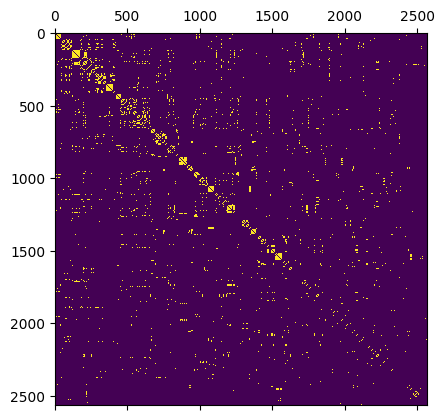

In [11]:
plt.matshow(adj_matrix)

In [12]:
clustering = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=45)

In [13]:
print(clustering[0:100])

[38 38 38 38 38 38 38 38 38 38 38 38 38  1 38 38 38 38 38 38 38 38 38 38
 38 38 38 38 38 38 38 38 38 38 38 38 38 38 38 38 35 35 35 35 35 35 35 35
 35 35 32 32 43 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 35 35
 35 35 35 35 35 35 35 35 32  1 32 32 32 32 32 32 32 32 32 32 32 32 32 43
 32 32 32 43]


45
Cluster 0: 78 players
Cluster 1: 142 players
Cluster 2: 6 players
Cluster 3: 7 players
Cluster 4: 7 players
Cluster 5: 6 players
Cluster 6: 6 players
Cluster 7: 7 players
Cluster 8: 21 players
Cluster 9: 10 players
Cluster 10: 10 players
Cluster 11: 63 players
Cluster 12: 9 players
Cluster 13: 23 players
Cluster 14: 16 players
Cluster 15: 68 players
Cluster 16: 81 players
Cluster 17: 93 players
Cluster 18: 70 players
Cluster 19: 10 players
Cluster 20: 130 players
Cluster 21: 83 players
Cluster 22: 69 players
Cluster 23: 24 players
Cluster 24: 56 players
Cluster 25: 44 players
Cluster 26: 69 players
Cluster 27: 94 players
Cluster 28: 73 players
Cluster 29: 83 players
Cluster 30: 99 players
Cluster 31: 75 players
Cluster 32: 122 players
Cluster 33: 97 players
Cluster 34: 54 players
Cluster 35: 112 players
Cluster 36: 83 players
Cluster 37: 59 players
Cluster 38: 58 players
Cluster 39: 97 players
Cluster 40: 19 players
Cluster 41: 52 players
Cluster 42: 45 players
Cluster 43: 61 player

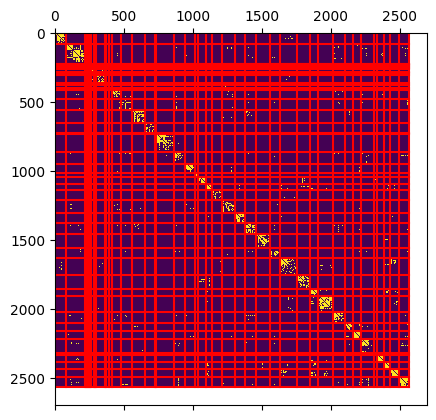

In [14]:
from utils.visualize import plot_adj_matrix_sorted_by_clustering

plot_adj_matrix_sorted_by_clustering(adj_matrix, clustering)

In [15]:
league_to_region_dict = {"LFL2":"EU", 
"LPL": "CN", 
"LCKC": "KR", 
"LVP SL": "EU", 
"LCK" : "KR", 
"NLC": "EU", 
"LCP": "APAC",
"LEC": "EU",
"HLL": "EU",
"PRM": "EU", 
"LFL": "EU",
"LIT": "EU",
"TCL": "EU",
"HW": "EU",
"LJL": "JP",
"LTA S": "LAT",
"LTA N": "NA",
"RL": "EU",
"NEXO": "EU", 
"CD": "LAT",
"EBL": "EU",
"PCS": "APAC", 
"ROL": "EU",
"LPLOL": "EU", 
"AL": "EU",
"LTA": "NA",
"VCS": "APAC",
"FST": "INT",
"EM": "EU",
"LRS": "LAT",
"LRN": "LAT",
"NACL": "NA", 
"LAS": "KR",
"HC": "EU", 
"PRMP": "EU",
"HM": "EU", 
"CT": "EU",
"Asia Master": "INT",
"MSI": "INT",
"EWC": "INT",
"WLDs": "INT",
"ASI": "INT",
"IC": "EU",
"KeSPA": "KR",
"DCup": "CN"
}

In [16]:
data_unique = data[["playerid"]].drop_duplicates(subset=["playerid"]).reset_index(drop=True)

playerid_to_league = data.groupby("playerid")["league"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict()
playerid_to_league
print("Total number of leagues:", len(data["league"].unique()))

data_unique["best_league"] = data_unique["playerid"].map(lambda x: playerid_to_league[x])
value_to_label_dict = {value: idx for idx, value in enumerate(data_unique["best_league"].unique())}
label_to_value_dict = {idx: value for idx, value in enumerate(data_unique["best_league"].unique())}
print("Number of leagues which appear as 'mode':", len(value_to_label_dict))

data_unique["cluster_pred"] = data_unique["playerid"].map(lambda x: clustering[playerid_to_adj_index[x]])
data_unique["cluster_true"] = data_unique["playerid"].map(lambda x: value_to_label_dict[playerid_to_league[x]])
data_unique

Total number of leagues: 45
Number of leagues which appear as 'mode': 39


,playerid,best_league,cluster_pred,cluster_true
0,oe:player:c659697694306de62d978569b84c344,LFL2,38,0
1,oe:player:dbdc61a1c41acedcbc7d399727155ac,LFL2,38,0
2,oe:player:694d028e62f4ea668b206ab752b6f94,LFL2,38,0
3,oe:player:90704735ca9fc01f2244f23f6e5d635,AL,38,1
4,oe:player:74f3f60a44ee916ecc257a5381be756,LFL2,38,0
...,...,...,...,...
2562,oe:player:c047390b97913db5db515101aea5b88,DCup,35,37
2563,oe:player:a5236fe7c89eb4c55defa16007158ee,DCup,35,37
2564,oe:player:7334616e303b11d70b3f50a76e197a1,DCup,35,37
2565,oe:player:1b9b0d1e4f341b3f5837485f68029e7,DCup,35,37


In [17]:
#value counts for cluster_true
data_unique["cluster_true"].value_counts()

cluster_true
11    133
29    112
14    107
26    100
3      97
28     96
13     93
8      90
27     89
2      88
32     84
1      80
30     78
31     78
19     75
34     73
24     70
20     68
21     66
4      65
15     64
22     63
6      62
17     62
0      61
7      59
9      59
12     54
5      51
16     51
35     49
18     46
23     45
25     43
37     16
33     14
36     13
10      8
38      5
Name: count, dtype: int64

In [18]:
from sklearn.metrics import normalized_mutual_info_score
nmi_score = normalized_mutual_info_score(data_unique["cluster_true"], data_unique["cluster_pred"])
print(f"NMI score: {nmi_score:.4f}")

NMI score: 0.8949


In [19]:
# Get all playerids from each cluster_pred as a cluster_pred_to_playerids
cluster_pred_to_league = {}
cluster_pred_to_playerids = data_unique.groupby("cluster_pred")["playerid"].apply(list).to_dict()
for cluster_pred, playerids in cluster_pred_to_playerids.items():
    league_mode = data[data["playerid"].isin(playerids)]["league"].mode().iloc[0]
    cluster_pred_to_league[cluster_pred] = league_mode

print(cluster_pred_to_league)


{0: 'PCS', 1: 'LFL', 2: 'ROL', 3: 'PRMP', 4: 'LFL2', 5: 'LRS', 6: 'LRN', 7: 'LRN', 8: 'VCS', 9: 'PRMP', 10: 'LCP', 11: 'VCS', 12: 'LPLOL', 13: 'NLC', 14: 'LPLOL', 15: 'RL', 16: 'ROL', 17: 'HC', 18: 'LRS', 19: 'HLL', 20: 'NEXO', 21: 'EBL', 22: 'AL', 23: 'NLC', 24: 'LRN', 25: 'LTA N', 26: 'LJL', 27: 'NLC', 28: 'LAS', 29: 'HM', 30: 'CD', 31: 'LPLOL', 32: 'LCKC', 33: 'NACL', 34: 'LCP', 35: 'LPL', 36: 'HLL', 37: 'LIT', 38: 'LFL2', 39: 'PRM', 40: 'LRN', 41: 'LEC', 42: 'LTA S', 43: 'LCK', 44: 'LVP SL'}


In [20]:

data_unique["best_league_pred"] = data_unique["cluster_pred"].map(lambda x: cluster_pred_to_league[x])
data_unique["best_league_true"] = data_unique["cluster_true"].map(lambda x: label_to_value_dict[x])

In [21]:
data_unique

,playerid,best_league,cluster_pred,cluster_true,best_league_pred,best_league_true
0,oe:player:c659697694306de62d978569b84c344,LFL2,38,0,LFL2,LFL2
1,oe:player:dbdc61a1c41acedcbc7d399727155ac,LFL2,38,0,LFL2,LFL2
2,oe:player:694d028e62f4ea668b206ab752b6f94,LFL2,38,0,LFL2,LFL2
3,oe:player:90704735ca9fc01f2244f23f6e5d635,AL,38,1,LFL2,AL
4,oe:player:74f3f60a44ee916ecc257a5381be756,LFL2,38,0,LFL2,LFL2
...,...,...,...,...,...,...
2562,oe:player:c047390b97913db5db515101aea5b88,DCup,35,37,LPL,DCup
2563,oe:player:a5236fe7c89eb4c55defa16007158ee,DCup,35,37,LPL,DCup
2564,oe:player:7334616e303b11d70b3f50a76e197a1,DCup,35,37,LPL,DCup
2565,oe:player:1b9b0d1e4f341b3f5837485f68029e7,DCup,35,37,LPL,DCup


In [22]:
regions = dict.fromkeys(set(league_to_region_dict.values()), 0)
regions

{'CN': 0, 'NA': 0, 'EU': 0, 'INT': 0, 'KR': 0, 'APAC': 0, 'LAT': 0, 'JP': 0}

In [23]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]
# Do me n colors
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff', '#000000']

color_labels = [colors[x] for x in labels]



NameError: name 'labels' is not defined

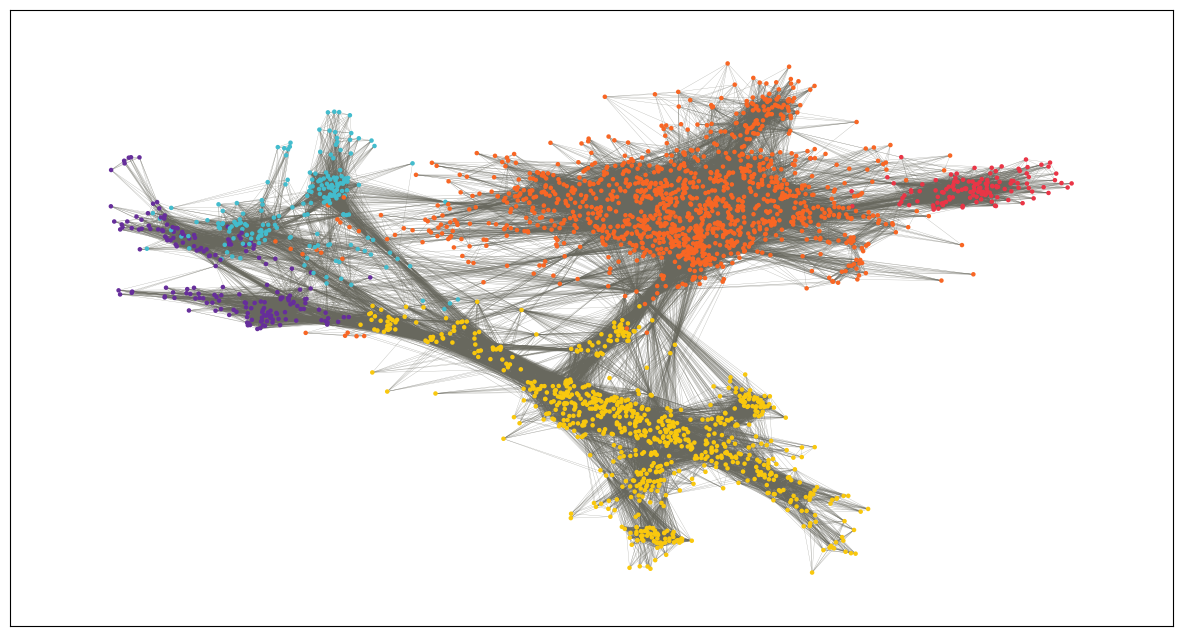

In [ ]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [ ]:
layout

{0: array([0.07271904, 0.29885406]),
 1: array([0.01733373, 0.27444447]),
 2: array([0.06220782, 0.28256087]),
 3: array([0.05537502, 0.20356287]),
 4: array([0.06521362, 0.28710491]),
 5: array([0.04611042, 0.30373953]),
 6: array([0.04186432, 0.29743603]),
 7: array([0.0789558 , 0.28552884]),
 8: array([0.08043143, 0.29338019]),
 9: array([0.05024773, 0.29472013]),
 10: array([0.0537212 , 0.23520877]),
 11: array([0.0587925 , 0.27000825]),
 12: array([0.06110446, 0.26101406]),
 13: array([0.07486729, 0.19222973]),
 14: array([0.05433026, 0.31054141]),
 15: array([0.03419586, 0.30767838]),
 16: array([0.01029864, 0.40240426]),
 17: array([-0.01509834,  0.26499745]),
 18: array([0.0893808 , 0.24794656]),
 19: array([0.08801728, 0.32260731]),
 20: array([0.01546246, 0.31939144]),
 21: array([0.06884031, 0.29085992]),
 22: array([0.03655196, 0.26903086]),
 23: array([0.04758326, 0.2965021 ]),
 24: array([0.04586398, 0.22511783]),
 25: array([-0.05777623,  0.10483949]),
 26: array([0.0570

15
Cluster 0: 362 players
Cluster 1: 352 players
Cluster 2: 222 players
Cluster 3: 209 players
Cluster 4: 201 players
Cluster 5: 193 players
Cluster 6: 174 players
Cluster 7: 170 players
Cluster 8: 169 players
Cluster 9: 131 players
Cluster 10: 118 players
Cluster 11: 104 players
Cluster 12: 94 players
Cluster 13: 73 players
Cluster 14: 54 players


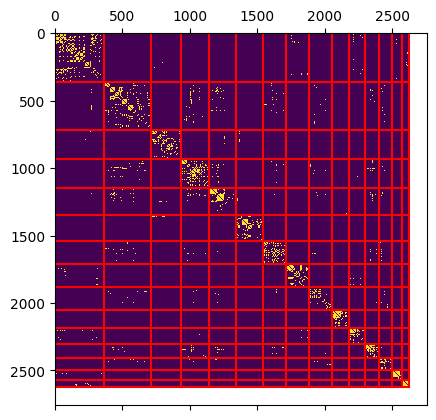

In [ ]:
from sknetwork.clustering import Louvain
louvain = Louvain()
labels = louvain.fit_predict(adj_matrix)
plot_adj_matrix_sorted_by_clustering(adj_matrix, labels)

In [ ]:
from sknetwork.ranking import PageRank
pagerank = PageRank()

In [ ]:
G = nx.from_numpy_array(adj_matrix)

In [ ]:
# Reimport utils.visualize
import importlib
import utils.visualize
importlib.reload(utils.visualize)
# No way dude thanks
from utils.visualize import count_cluster_regions

count_cluster_regions(labels, uniq_player_ids, data)

0
{'APAC': 54, 'LAT': 2, 'EU': 6, 'CN': 174, 'KR': 213, 'JP': 0, 'NA': 69, 'INT': 321}
__
1
{'APAC': 2, 'LAT': 1, 'EU': 545, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 1, 'INT': 0}
__
2
{'APAC': 0, 'LAT': 263, 'EU': 0, 'CN': 0, 'KR': 1, 'JP': 0, 'NA': 30, 'INT': 15}
__
3
{'APAC': 1, 'LAT': 0, 'EU': 323, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 2, 'INT': 0}
__
4
{'APAC': 0, 'LAT': 1, 'EU': 387, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 0, 'INT': 0}
__
5
{'APAC': 0, 'LAT': 104, 'EU': 1, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 121, 'INT': 0}
__
6
{'APAC': 0, 'LAT': 0, 'EU': 290, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 0, 'INT': 0}
__
7
{'APAC': 96, 'LAT': 0, 'EU': 0, 'CN': 0, 'KR': 4, 'JP': 82, 'NA': 0, 'INT': 47}
__
8
{'APAC': 0, 'LAT': 0, 'EU': 211, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 0, 'INT': 0}
__
9
{'APAC': 0, 'LAT': 0, 'EU': 217, 'CN': 0, 'KR': 0, 'JP': 0, 'NA': 0, 'INT': 0}
__
10
{'APAC': 101, 'LAT': 0, 'EU': 1, 'CN': 1, 'KR': 0, 'JP': 0, 'NA': 0, 'INT': 47}
__
11
{'APAC': 0, 'LAT': 0, 'EU': 145, 'CN': 0, 'KR': 0, 'JP': 0, 

In [ ]:
G.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 145), (0, 340), (0, 503), (0, 524), (0, 525), (0, 527), (0, 530), (0, 577), (0, 819), (0, 986), (0, 989), (0, 1003), (0, 1007), (0, 1028), (0, 1149), (0, 1207), (0, 1273), (0, 1832), (0, 1837), (0, 1838), (0, 1839), (0, 1872), (0, 1906), (0, 2019), (0, 2046), (0, 2050), (0, 2308), (0, 2309), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 145), (1, 266

In [ ]:
# modified from https://plotly.com/python/network-graphs/
import plotly.graph_objects as go
G = nx.random_geometric_graph(200, 0.125)

edge_x = []
edge_y = []
for edge in G

SyntaxError: expected ':' (2112794318.py, line 7)